In [85]:

import torch.nn as nn
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

In [86]:
G=5
T=600
estadistica='promedio'
hidden=(10,10) 
path_uniform = f"symmetric/{G}redes{estadistica}/nets_best_by_gid_uniform_{T}.pt"
path_discriminatory = f"symmetric/{G}redes{estadistica}/nets_best_by_gid_pay_as_bid_{T}.pt"

In [87]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PolicyNet(nn.Module):
    def __init__(self, input_dim: int, hidden=(10,10), output_dim: int = 1,
                 floor_mode: str = "max", min_bid: float = 1e-6):
        super().__init__()
        layers = []
        d = int(input_dim)
        for h in hidden:
            layers += [nn.Linear(d, int(h)), nn.ReLU()]
            d = int(h)
        layers += [nn.Linear(d, int(output_dim))]
        self.net = nn.Sequential(*layers)

        # parámetros “no entrenables” (puedes cambiar por llamada)
        self.floor_mode = floor_mode
        self.min_bid = float(min_bid)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Devuelve BID factible:
          r(x) = f_theta(x)              (salida latente)
          bid = Gamma_phi(r(x))         (transformación factible)
          bid >= phi  (si x es phi escalar) o bid >= max_h phi_h / mean_h phi_h
        """
        raw = self.net(x).reshape(-1)   # salida latente r(x)

        if x.ndim == 2 and x.shape[1] > 1:
            if self.floor_mode == "max":
                floor = x.max(dim=1).values
            elif self.floor_mode == "mean":
                floor = x.mean(dim=1)
            else:
                raise ValueError("floor_mode must be 'max' or 'mean'")
        else:
            floor = x.reshape(-1)

        floor = torch.clamp_min(floor, 0.0)
        if G==5:
            bid = floor + F.softplus(raw)-0.1  #-0.25 frp G=5
        elif G==36:
            bid = floor + F.softplus(raw)+0.1
        else:
            bid = floor + F.softplus(raw)
            

        return bid


In [88]:

saved_nets_uniform = torch.load(path_uniform, map_location="cpu")

gid = 1
net_uniform = PolicyNet(
    input_dim=24,
    hidden=hidden,
    output_dim=1,
    floor_mode="mean",   # <- igual que en entrenamiento
    min_bid=1e-6         # <- igual que en entrenamiento
)
net_uniform.load_state_dict(saved_nets_uniform[gid], strict=True)
net_uniform.eval() # importante para modo evaluación




saved_nets_discriminatory = torch.load(path_discriminatory, map_location="cpu")

gid = 1
net_discriminatory = PolicyNet(
    input_dim=24,
    hidden=hidden,
    output_dim=1,
    floor_mode="mean",   # <- igual que en entrenamiento
    min_bid=1e-6         # <- igual que en entrenamiento
)
net_discriminatory.load_state_dict(saved_nets_discriminatory[gid], strict=True)
net_discriminatory.eval() # importante para modo evaluación

PolicyNet(
  (net): Sequential(
    (0): Linear(in_features=24, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [89]:
CSV_PATH = "symmetric/grupos.csv"   # <-- adjust
input = pd.read_csv(CSV_PATH)


In [90]:
input

,id_planta,Fecha,phi,Grupo,precio_d
0,1,2025-04-01,0.083924,1,0.10137
1,2,2025-04-01,0.262222,5,0.28295
2,3,2025-04-01,0.275288,5,0.32637
3,4,2025-04-01,0.260380,5,0.31037
4,5,2025-04-01,0.968472,4,1.02813
...,...,...,...,...,...
4207,32,2025-09-09,0.779362,4,0.90894
4208,33,2025-09-09,1.058581,4,1.11735
4209,34,2025-09-09,0.945489,4,1.01274
4210,35,2025-09-09,0.969786,4,1.18348


In [91]:
import torch

# Suponiendo que tu DataFrame se llama input
def phi_a_tensor_24(phi_val):
    """Recibe un valor escalar y devuelve un tensor (1,24) duplicado"""
    arr = [phi_val] * 24  # lista de 24 valores iguales
    return torch.tensor([arr], dtype=torch.float)  # shape (1,24)
# Lista para guardar resultados

predicciones_uniform = []
predicciones_discriminatory = []
for i, row in input.iterrows():
    x = phi_a_tensor_24(row['phi'])
    y_pred_uniform = net_uniform(x)
    y_pred_discrimininatoty = net_discriminatory(x)
    predicciones_uniform.append(y_pred_uniform.item())  # convertir de tensor a float
    predicciones_discriminatory.append(y_pred_discrimininatoty.item()) 

In [92]:
predicciones_uniform

[0.20464524626731873,
 0.38288769125938416,
 0.39596015214920044,
 0.3810449540615082,
 1.0893391370773315,
 0.41081616282463074,
 0.21656164526939392,
 0.20634576678276062,
 0.33797764778137207,
 0.35185882449150085,
 0.3771495521068573,
 0.38488462567329407,
 0.34382906556129456,
 0.4472021162509918,
 0.4863576591014862,
 0.9822437763214111,
 0.9886415004730225,
 0.3472207188606262,
 0.6248315572738647,
 0.6132765412330627,
 1.4776220321655273,
 1.3088219165802002,
 0.3472207188606262,
 0.15737566351890564,
 2.412332057952881,
 0.4660279452800751,
 1.8214927911758423,
 1.7255492210388184,
 0.9517829418182373,
 0.8355917930603027,
 0.8733671307563782,
 1.0293513536453247,
 1.5339523553848267,
 1.5402518510818481,
 1.2386157512664795,
 1.477782964706421,
 0.1924799680709839,
 1.0674960613250732,
 0.34895798563957214,
 0.344230979681015,
 1.093880295753479,
 0.40579691529273987,
 0.21196803450584412,
 0.20498427748680115,
 0.31243881583213806,
 0.31527450680732727,
 0.3573719561100006,


In [93]:
predicciones_discriminatory

[0.296698659658432,
 0.47486451268196106,
 0.48792317509651184,
 0.4730236828327179,
 1.180687427520752,
 0.5027635097503662,
 0.3086032569408417,
 0.2983975112438202,
 0.4299953281879425,
 0.4438683092594147,
 0.4691323935985565,
 0.47685936093330383,
 0.4358467161655426,
 0.5391111373901367,
 0.5782254934310913,
 1.073678970336914,
 1.0800715684890747,
 0.43923506140708923,
 0.716555118560791,
 0.7050113677978516,
 1.5685986280441284,
 1.3999918699264526,
 0.43923506140708923,
 0.24947047233581543,
 2.5021169185638428,
 0.5579171180725098,
 1.9120181798934937,
 1.8162035942077637,
 1.0432428121566772,
 0.9271460771560669,
 0.964890718460083,
 1.1207482814788818,
 1.6248611211776733,
 1.6311529874801636,
 1.3298426866531372,
 1.5687593221664429,
 0.28454458713531494,
 1.1588619947433472,
 0.44097045063972473,
 0.43624845147132874,
 1.1852248907089233,
 0.49774959683418274,
 0.3040142357349396,
 0.2970373332500458,
 0.40445849299430847,
 0.4072934687137604,
 0.44937559962272644,
 0.487

In [94]:
input['est_uni']=predicciones_uniform
input['est_dis']=predicciones_discriminatory
input['diff']=input['est_dis']-input['est_uni']

<Figure size 3600x1500 with 0 Axes>

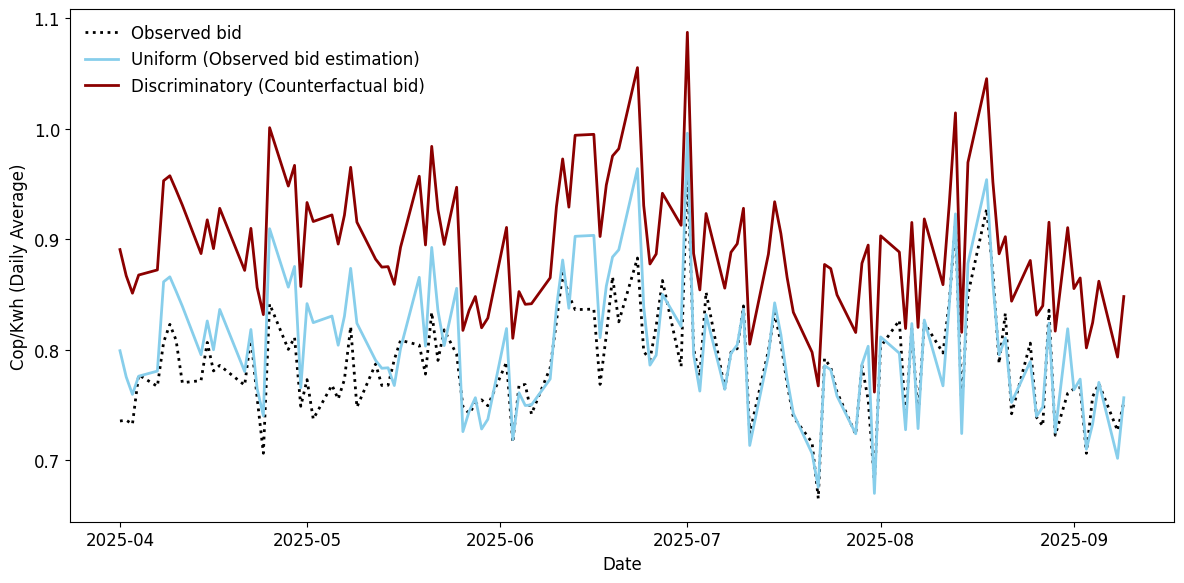

In [95]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams.update({
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False
})

# Asegurarse que "Fecha" es datetime
input["Fecha"] = pd.to_datetime(input["Fecha"])

# --- Agrupar por fecha y calcular promedio de todas las plantas ---
df_daily = input.groupby(input["Fecha"].dt.date)[
    ["precio_d", "est_uni", "est_dis"]
].mean().reset_index()

plt.figure(figsize=(12,5), dpi=300)

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams.update({
    "font.size": 12,
    "axes.spines.top": True,
    "axes.spines.right": True
})

# Asegurarse que "Fecha" es datetime
input["Fecha"] = pd.to_datetime(input["Fecha"])

# Agrupar por fecha y calcular promedio
df_daily = input.groupby(input["Fecha"].dt.date)[
    ["precio_d", "est_uni", "est_dis"]
].mean().reset_index()

plt.figure(figsize=(12,6))

# --- Líneas con colores y estilos ---
plt.plot(df_daily["Fecha"], df_daily["precio_d"], label="Observed bid",
         color="black", linestyle=":", linewidth=2)        # línea punteada
plt.plot(df_daily["Fecha"], df_daily["est_uni"], label="Uniform (Observed bid estimation)",
         color="skyblue", linewidth=2)
plt.plot(df_daily["Fecha"], df_daily["est_dis"], label="Discriminatory (Counterfactual bid)",
         color="darkred", linewidth=2)


plt.xlabel("Date")
plt.ylabel("Cop/Kwh (Daily Average)")
#plt.title("Promedio diario por fecha de todas las plantas")
plt.legend(frameon=False)
plt.grid(False)
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(f'symmetric/{G}redes{estadistica}/bid_comparison_{T}.png', dpi=300, bbox_inches='tight')
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_33368\2379210048.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


<Figure size 3600x1500 with 0 Axes>

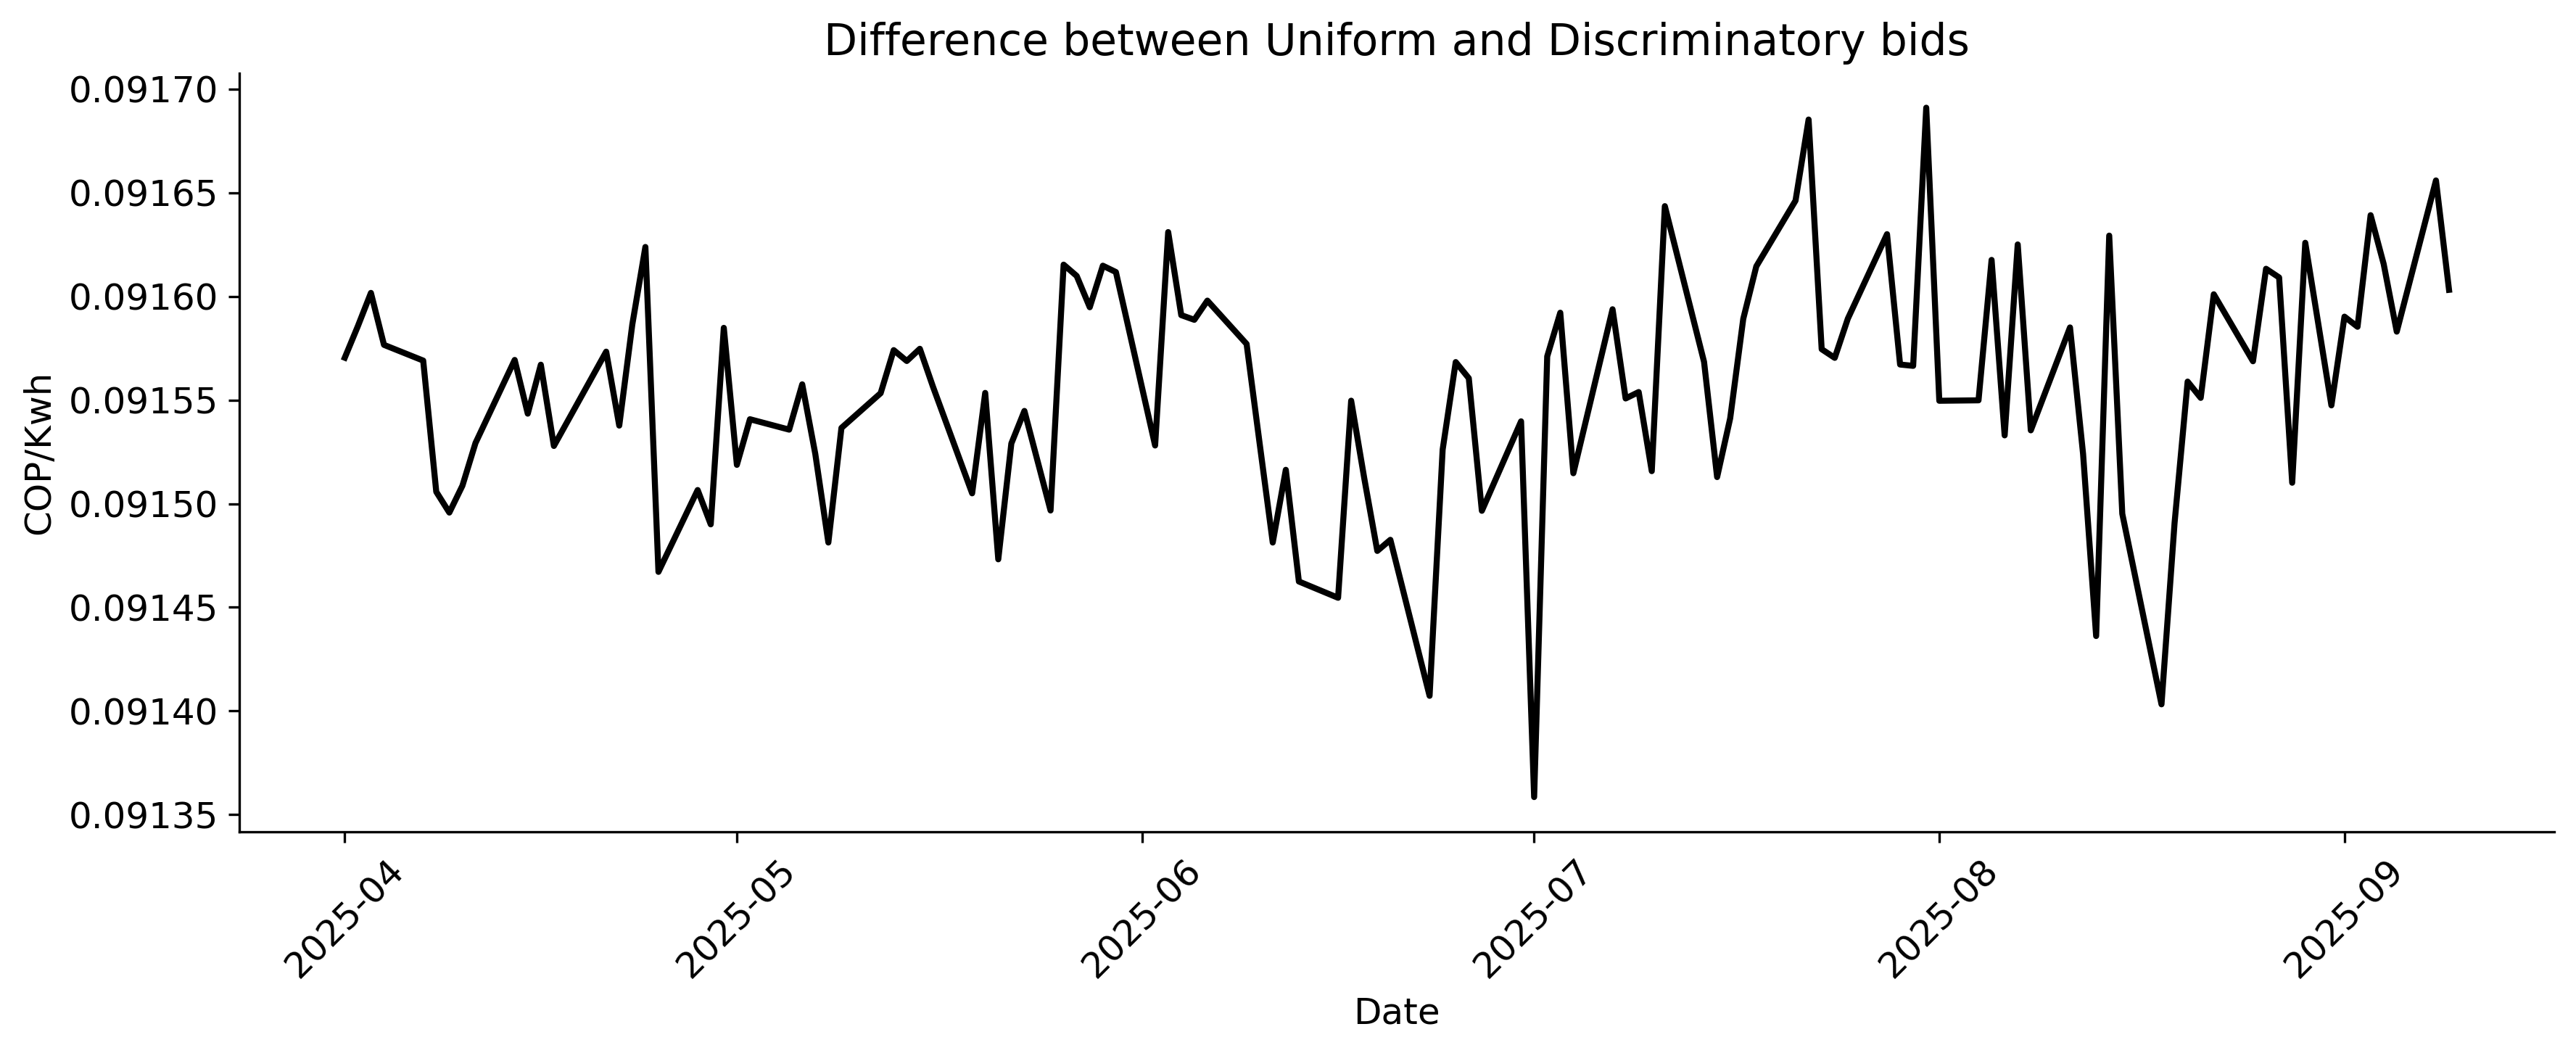

In [96]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams.update({
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False
})

# Asegurarse que "Fecha" es datetime
input["Fecha"] = pd.to_datetime(input["Fecha"])

# --- Agrupar por fecha y calcular promedio de todas las plantas ---
df_daily = input.groupby(input["Fecha"].dt.date)[
    ['diff']
].mean().reset_index()

plt.figure(figsize=(12,5), dpi=300)

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams.update({
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False
})

# Asegurarse que "Fecha" es datetime
input["Fecha"] = pd.to_datetime(input["Fecha"])

# Agrupar por fecha y calcular promedio
df_daily = input.groupby(input["Fecha"].dt.date)[
    ['diff']
].mean().reset_index()

plt.figure(figsize=(12,5), dpi=300)

# --- Líneas con colores y estilos ---
plt.plot(df_daily["Fecha"], df_daily["diff"],
         color="black", linewidth=2)        # línea punteada

plt.xlabel("Date")
plt.ylabel("COP/Kwh")
plt.title("Difference between Uniform and Discriminatory bids")
plt.legend(frameon=False)
plt.grid(False)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [97]:
df_daily['diff'].describe()

count    117.000000
mean       0.091555
std        0.000056
min        0.091358
25%        0.091524
50%        0.091559
75%        0.091590
max        0.091691
Name: diff, dtype: float64

## Equilibrios

In [98]:
import torch
import torch.nn.functional as F

x = phi_a_tensor_24(1.255597)
with torch.no_grad():
    raw = net_uniform.net(x).reshape(-1)
    if x.ndim == 2 and x.shape[1] > 1:
        phi_floor = x.max(dim=1).values if net_uniform.floor_mode == "max" else x.mean(dim=1)
    else:
        phi_floor = x.reshape(-1)
    phi_floor = torch.clamp_min(phi_floor, 0.0)
    bid = phi_floor + F.softplus(raw) + net_uniform.min_bid


print("raw:", raw.item())
print("phi floor:", phi_floor.item())
print("bid:", bid.item())
print("bid-phi_floor:", (bid - phi_floor).item())

raw: -1.3974279165267944
phi floor: 1.2555968761444092
bid: 1.4765245914459229
bid-phi_floor: 0.22092771530151367


In [99]:
import torch
import torch.nn.functional as F

x = phi_a_tensor_24(1.255597)
with torch.no_grad():
    raw = net_discriminatory.net(x).reshape(-1)
    inc = F.softplus(raw)
    bid = net_discriminatory(x).reshape(-1)

print("raw:", raw.item())
print("softplus(raw):", inc.item())
print("bid:", bid.item(), "phi:", x.mean().item(), "bid-phi:", (bid - x.mean()).item())

raw: -1.0046055316925049
softplus(raw): 0.31202512979507446
bid: 1.467621922492981 phi: 1.2555968761444092 bid-phi: 0.21202504634857178


## notas:
en maximo da bien, uniform es mas pequeño que discirminatory bien

## Beneficios

In [100]:
CSV_PATH = "symmetric/df_con_grupos.csv"   # <-- adjust
df = pd.read_csv(CSV_PATH)


In [101]:
df['est_uni']=predicciones_uniform
df['est_dis']=predicciones_discriminatory

In [102]:
df

,CodigoPlanta,available_q,phi,precio_d,Fecha,cluster,id_planta,daily_reman_demand,Grupo,est_uni,est_dis
0,TYP3,"[49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49....",0.083924,0.10137,2025-04-01,10.0,1,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",1,0.204645,0.296699
1,TYP2,"[26.0, 26.0, 26.0, 26.0, 26.0, 26.0, 26.0, 26....",0.262222,0.28295,2025-04-01,,2,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",1,0.382888,0.474865
2,TSJ2,"[170.0, 170.0, 170.0, 170.0, 170.0, 170.0, 170...",0.275288,0.32637,2025-04-01,10.0,3,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",1,0.395960,0.487923
3,TSJ1,"[165.0, 165.0, 165.0, 165.0, 165.0, 165.0, 165...",0.260380,0.31037,2025-04-01,10.0,4,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",1,0.381045,0.473024
4,MRL1,"[164.0, 164.0, 164.0, 164.0, 164.0, 164.0, 164...",0.968472,1.02813,2025-04-01,10.0,5,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",1,1.089339,1.180687
...,...,...,...,...,...,...,...,...,...,...,...
4207,TRN1,"[80.0, 80.0, 80.0, 80.0, 80.0, 80.0, 80.0, 80....",0.779362,0.90894,2025-09-09,12.0,32,"[1092.15, 1009.76, 945.22, 868.33, 808.01, 733...",1,0.900190,0.991692
4208,TBQ4,"[60.0, 60.0, 60.0, 60.0, 60.0, 60.0, 60.0, 60....",1.058581,1.11735,2025-09-09,12.0,33,"[1092.15, 1009.76, 945.22, 868.33, 808.01, 733...",1,1.179467,1.270742
4209,TBQ3,"[60.0, 60.0, 60.0, 60.0, 60.0, 60.0, 60.080980...",0.945489,1.01274,2025-09-09,12.0,34,"[1092.15, 1009.76, 945.22, 868.33, 808.01, 733...",1,1.066352,1.157719
4210,TVL1,"[241.0, 241.0, 241.0, 241.0, 241.0, 241.0, 241...",0.969786,1.18348,2025-09-09,12.0,35,"[1092.15, 1009.76, 945.22, 868.33, 808.01, 733...",1,1.090653,1.182000


In [103]:
sigma=1e-3
t=0
max(sigma, (sigma * 1e1)* (0.995 ** int(t)))


0.01

In [104]:
df.to_csv(f'symmetric/{G}redes{estadistica}/resultados_Estimaciones_{T}.csv', index=False)